In [8]:
%load_ext autoreload
%autoreload 2

%matplotlib inline
import matplotlib.pyplot as plt
import sigpy as sp
import pandas as pd
import sigpy.plot as pl
import numpy as np
import os
import jax as jx
ksp = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_ksp.npy")
coord = np.load(r"/Users/ayman/Library/CloudStorage/OneDrive-King'sCollegeLondon/Project/Sigpytutorial/projection_coord.npy")


import sys
from pathlib import Path

project_root = Path.cwd().parents[0]
sys.path.append(str(project_root))

print(project_root)

import aymansigmri as asm

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
/Users/ayman/Desktop/MSc Project Local/MSc-Project-ZTE


## Goal: Set up and test functions

In [28]:
width=4
gap = 2
num_iters = 50

resize_wid=1024
rw_div2 = int(resize_wid/2)

inner_wid=100
indiv2 = int(inner_wid/2)

In [6]:
zte_radial_kspacedlt, zte_radial_coordsdlt, zte_radial_kspacezero, zte_radial_coordszero, mask = asm.generate_zte_data(ksp=ksp, coord=coord, n_missing=(gap), undersampling_factor=1)


cartesian_zte = asm.nufft_gridding(kspace=zte_radial_kspacezero, coords=zte_radial_coordszero)

cartesian_kspace_enl = asm.zero_padding(cart_kspace=cartesian_zte, resize_x=resize_wid, resize_y=resize_wid)

inner_region, inner_mask, start, end = asm.inner_portion(enlarged_kspace=cartesian_kspace_enl, inner_sidelen=inner_wid)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


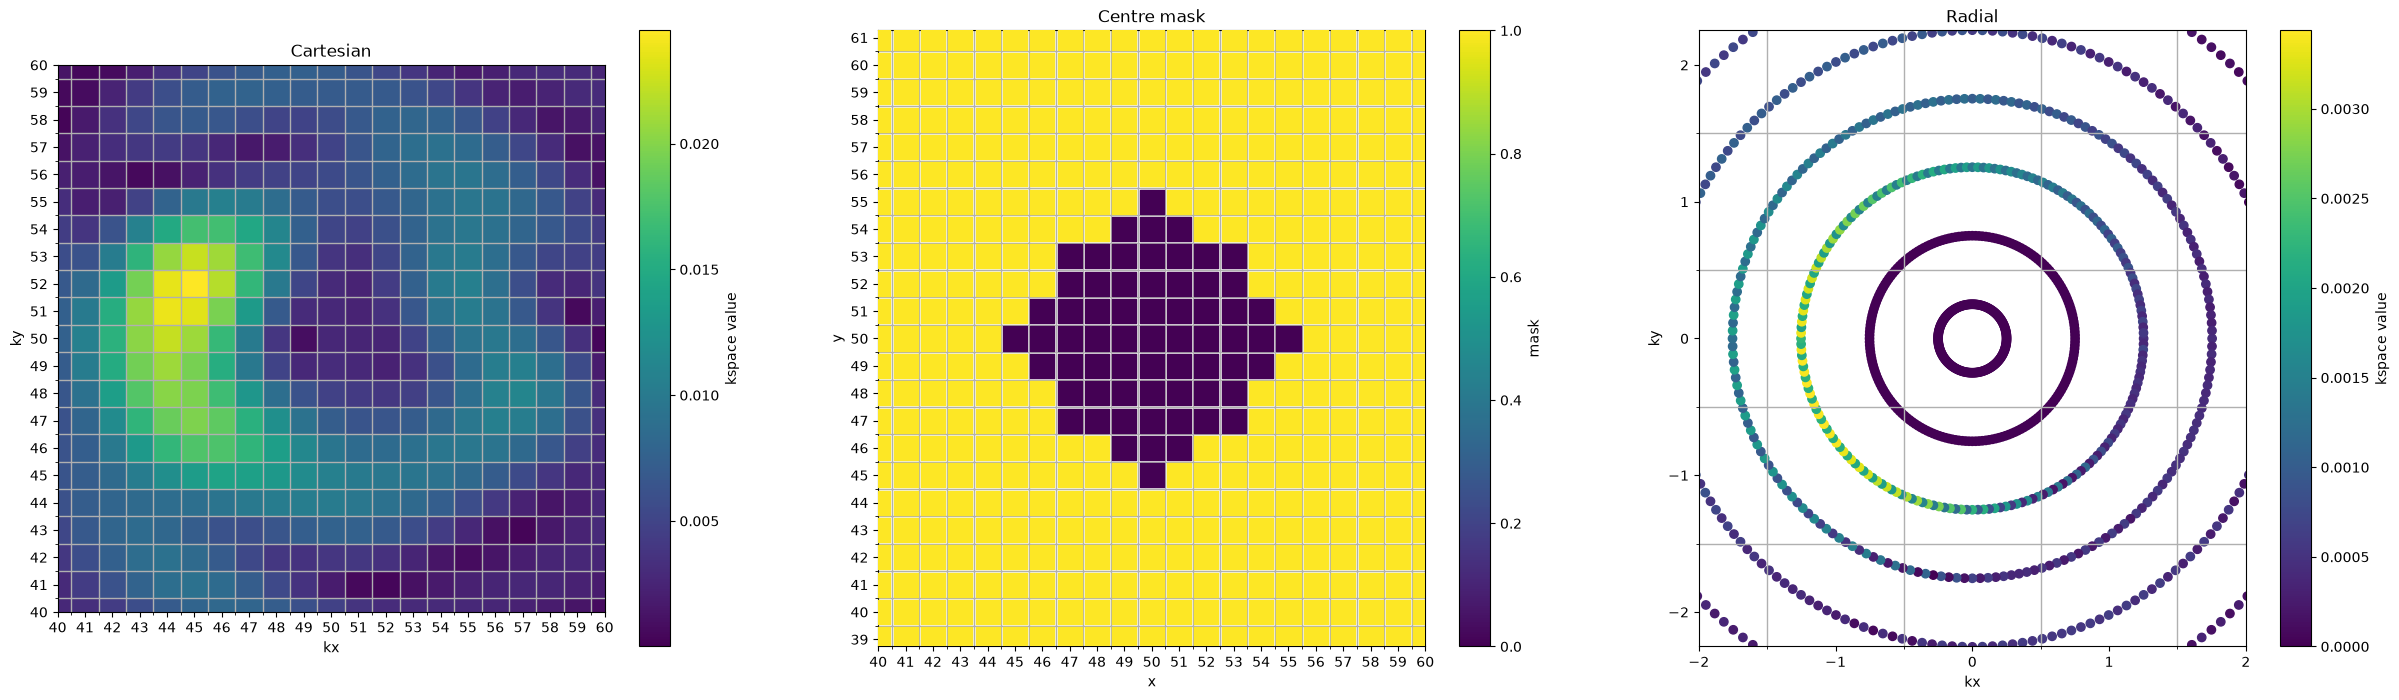

In [ ]:
cy, cx = inner_wid // 2, inner_wid // 2
r = 4
yy, xx = np.ogrid[:inner_wid, :inner_wid]
mask = (yy - cy)**2 + (xx - cx)**2 > r**2 +2

mask[(cx-5):(cx+6), cy] = False
mask[(cx), (cy-5):(cy+6)] = False


masked_inner = inner_region.copy()
masked_inner[:,~mask] = 0

inner_removed = inner_region.copy()
inner_removed[:,mask] = 0

totalwid = 1024
totaldiv = totalwid // 2

mask2 = np.ones((totalwid, totalwid), dtype=bool)

mask2[(indiv2-3):(indiv2+3), indiv2:indiv2+1] = False
mask2[(indiv2), (indiv2-2):(indiv2+3)] = False


asm.plot_mask(inner_region, mask=mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

In [3]:
rng = np.random.default_rng(0) 
arr1 = (rng.standard_normal((3,6,6)) + 1j*rng.standard_normal((3,6,6))).astype(np.complex64)

dataarray, N_c, N_x, N_y = asm.hankel(arr1, 5)

arr2 = asm.hankel_H_averaged(dataarray, N_c, Nx=6, Ny=6, w=5)

In [ ]:
def LORAKS_loop_hard(n_iters, window_size, zero_thresh, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    deltas = []
    k_prev = None
    iter_count = 0
    while iter_count < n_iters:
        hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
        U, S_reduced, Vh = asm.sig_val_thresholding_jax(data=hankel_matrix, zero_thresh=zero_thresh)
        data_recon = (U * S_reduced) @ Vh
        kspace_cart_coils_recon = asm.hankel_H_averaged(data_recon, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
        kspace_cart_coils_consistent = kspace_cart_coils_recon.copy()

        for coil in range(ksp_forhankel.shape[0]):
            kspace_cart_coils_consistent[coil, dtg_mask] = cartesian_inputkspace[coil, dtg_mask]
        ksp_forhankel = kspace_cart_coils_consistent.copy()

        vec = ksp_forhankel[:, ~mask]

        if k_prev is not None:
            deltas.append(np.linalg.norm(vec - k_prev) / np.linalg.norm(k_prev))
        k_prev = vec.copy()

        iter_count += 1

    output_kspace = ksp_forhankel.copy()
    return output_kspace, deltas

In [ ]:
window_size=8
lamda = 0.005
r = 50


I = np.identity(r)


ksp_forhankel = inner_region.copy()

ksp_zerod = ksp_forhankel * mask
X_H, _, N_x, N_y = asm.hankel(ksp_zerod, window_size)
M_H, *_ = asm.hankel(np.broadcast_to(mask, ksp_zerod.shape).astype(np.complex64), window_size)
M_H = np.real(M_H) > 0.5

dead = ~M_H.any(axis=0)
if dead.any():
    raise ValueError(
        f"{dead.sum()} patch positions see no measured data — increase w"
    )

#Initialise A=UD and B=VD
m,n = np.shape(X_H)
U = np.random.randn(m, r)
V = np.zeros(n*r).reshape(n,r)
D = I.copy()


A = np.dot(U,D)
B = np.dot(V,D)

names  = ("X_H", "M_H", "U", "V", "D", "A", "B")
inputs = (X_H, M_H, U, V, D, A, B)

for name, arr in zip(names, inputs):
    print(f"Shape of {name} is {arr.shape}")





Shape of X_H is (768, 8649)
Shape of M_H is (768, 8649)
Shape of U is (768, 50)
Shape of V is (8649, 50)
Shape of D is (50, 50)
Shape of A is (768, 50)
Shape of B is (8649, 50)


In [ ]:
def softimpute_ALS(X_H, M_H, rank, lamda, n_iters):
    I = np.eye(rank)
    m,n = np.shape(X_H)
    U = np.random.randn(m, rank)
    Q,R = np.linalg.qr(U)
    U = Q[:,0:r]
    V = np.zeros(n*rank).reshape(n,rank)
    D = I.copy()


    A = np.dot(U,D)
    B = np.dot(V,D)
    iter_count = 0
    while iter_count < n_iters:
        X_star = M_H * (X_H - A @ B.conj().T) #+ A @ B.conj().T

        A2 = np.linalg.inv(A.conj().T @ A + lamda*I)

        B = X_star.conj().T @ A @ A2

        X_star = M_H * (X_H - A @ B.conj().T) #+ A @ B.conj().T

        B2 = np.linalg.inv(B.conj().T @ B + lamda*I)

        A = X_star @ B @ B2

        ABt = A @ B.conj().T

        iter_count +=1
    return(ABt)

In [ ]:
ksp_forhankel = inner_region.copy()

ksp_zerod = ksp_forhankel * mask
X_H, _, N_x, N_y = asm.hankel(ksp_zerod, window_size)
M_H, *_ = asm.hankel(np.broadcast_to(mask, ksp_zerod.shape).astype(np.complex64), window_size)
M_H = np.real(M_H) > 0.5

In [ ]:
def LORAKS_imputeals(n_iters, window_size, cartesian_inputkspace, dtg_mask):
    ksp_forhankel = cartesian_inputkspace.copy()
    ksp_zerod = ksp_forhankel * dtg_mask
    masked_hankel, *_ = asm.hankel(np.broadcast_to(dtg_mask, ksp_zerod.shape).astype(np.complex64), window_size)
    masked_hankel = np.real(masked_hankel) > 0.5

    hankel_matrix, n_coils, Numx, Numy = asm.hankel(kspace=ksp_forhankel, w=window_size)
    
    filled_hankel = softimpute_ALS(X_H = hankel_matrix, M_H = masked_hankel, rank = rank, lamda = lam, n_iters=n_iters)
    
    kspace_cart_coils_recon = asm.hankel_H_averaged(filled_hankel, n_coils=ksp_forhankel.shape[0], Nx=ksp_forhankel.shape[1], Ny=ksp_forhankel.shape[2], w=window_size)
    kspace_cart_coils_recon = np.where(dtg_mask, cartesian_inputkspace, kspace_cart_coils_recon)
    output_kspace = kspace_cart_coils_recon.copy()
    return output_kspace

(768, 8649)

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


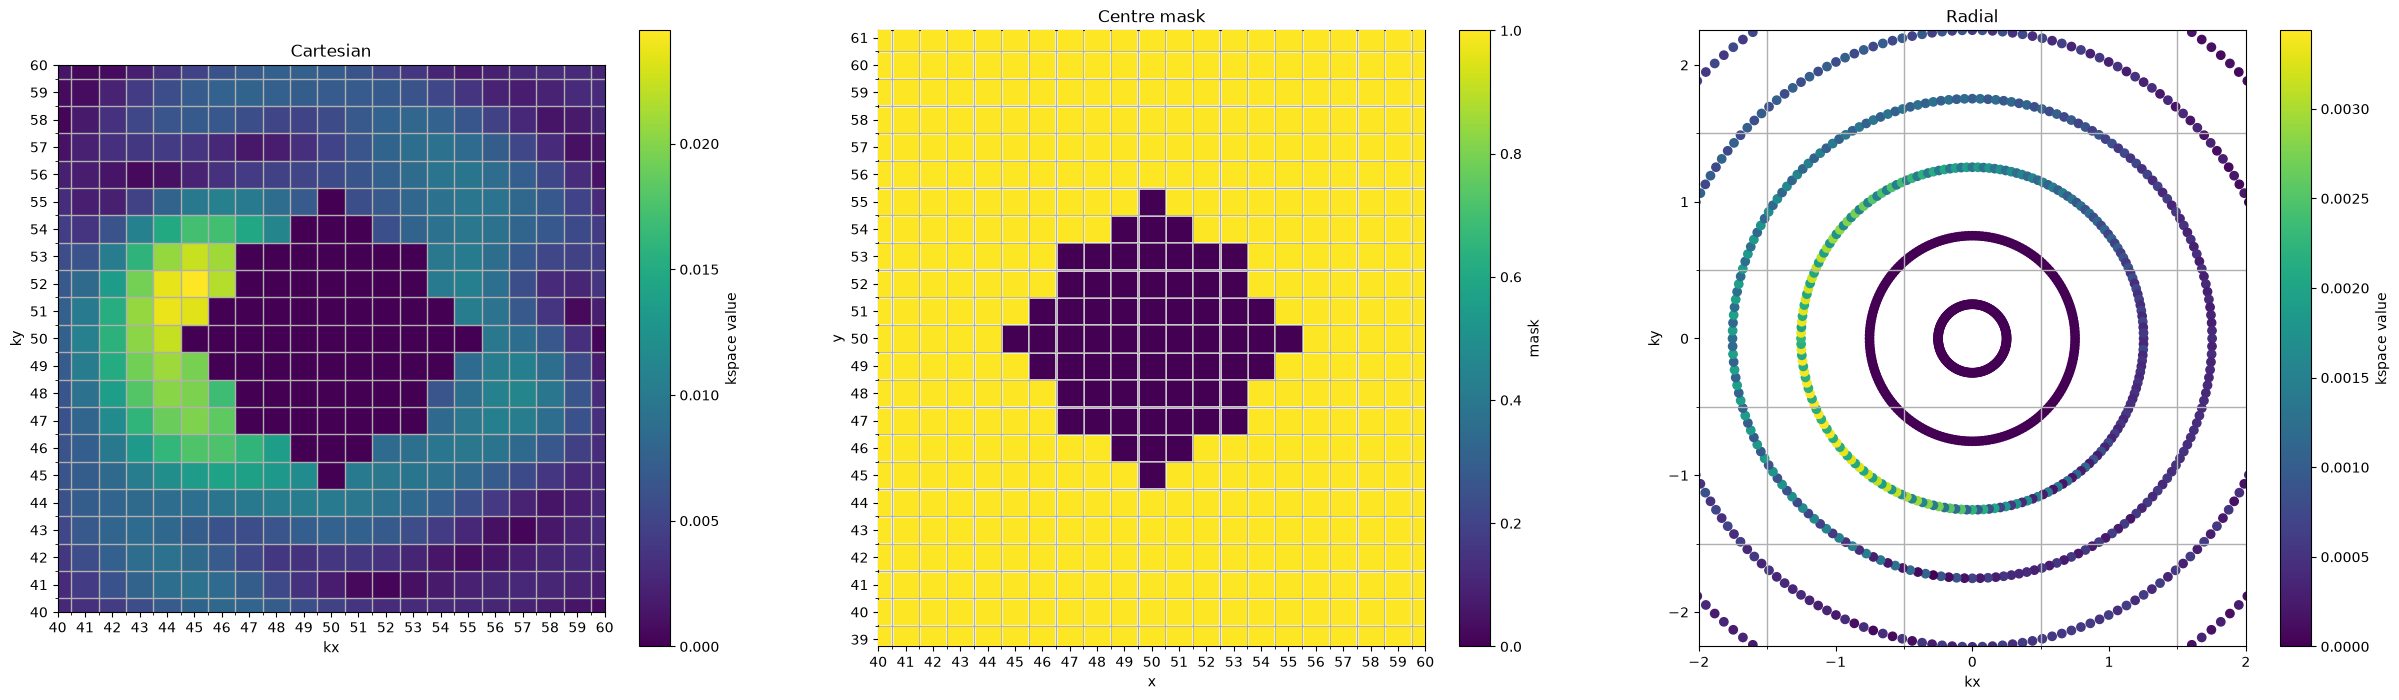

In [19]:
asm.plot_mask(ksp_zerod, mask, zte_radial_coords=zte_radial_coordszero, zte_radial_kspace=zte_radial_kspacezero, innersidelen=inner_wid,sidelencart=10,sidelenrad=4)

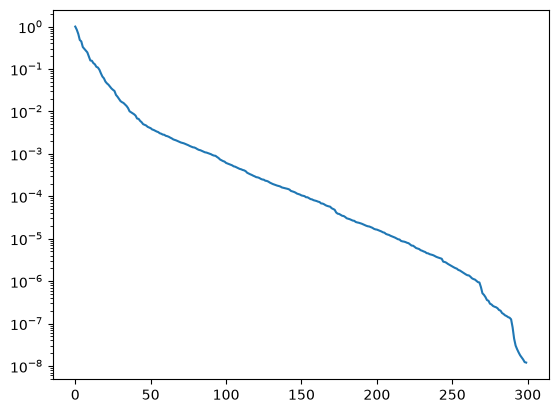

In [ ]:
def softimpute_als(kspace, mask, w, r, lam, n_iter=200, tol=1e-6):
    """
    Fill missing k-space (e.g. ZTE dead-time gap) via softImpute-ALS
    (Hastie et al. 2015, Algorithm 4.1) on the multicoil Hankel lift.

    kspace : (N_c, Nx, Ny) complex array; unmeasured entries can be anything
    mask   : (Nx, Ny) bool; True = measured sample
    w      : Hankel window size (must be large enough that every patch
             position overlaps at least one measured sample)
    r      : rank of the factorization A B^H
    lam    : ridge / nuclear-norm regularization (small, > 0)

    Returns: k_filled (N_c, Nx, Ny), obj (objective F per iteration)
    """
    N_c, Nx, Ny = kspace.shape

    # ---------- lift data and mask (once) ----------
    kdata = kspace * mask                          # zero the gap defensively
    X_H, _, N_x, N_y = asm.hankel(kdata, w)
    M_H, *_ = asm.hankel(
        np.broadcast_to(mask, kspace.shape).astype(np.complex64), w
    )
    M_H = np.real(M_H) > 0.5                       # (w²·N_c, N_x·N_y) bool

    # identifiability check: no patch position may be fully unobserved
    dead = ~M_H.any(axis=0)
    if dead.any():
        raise ValueError(
            f"{dead.sum()} patch positions see no measured data — increase w"
        )

    # ---------- initialize A, B: balanced rank-r split of zero-filled lift ----------
    U, s, Vh = np.linalg.svd(X_H, full_matrices=False)
    A = (U[:, :r] * np.sqrt(s[:r])).astype(np.complex64)          # (w²N_c, r)
    B = (Vh[:r].conj().T * np.sqrt(s[:r])).astype(np.complex64)   # (N_x·N_y, r)

    Ir = lam * np.eye(r, dtype=np.complex64)
    obj = []

    # ---------- Algorithm 4.1 ----------
    for it in range(n_iter):                                  # step 1
        # step 2: X* = P_Ω(X - AB^H) + AB^H  (sparse part only; AB^H implicit)
        S = M_H * (X_H - A @ B.conj().T)

        # step 3: A ← X*B (B^H B + λI)^{-1},  X*B = SB + A(B^H B)
        G = B.conj().T @ B
        A = np.linalg.solve((G + Ir).T, (S @ B + A @ G).T).T

        # step 4: refresh X* with the updated A
        S = M_H * (X_H - A @ B.conj().T)

        # step 5: B ← X*^H A (A^H A + λI)^{-1},  X*^H A = S^H A + B(A^H A)
        G = A.conj().T @ A
        B = np.linalg.solve((G + Ir).T, (S.conj().T @ A + B @ G).T).T

        # objective F(A,B) — must decrease monotonically (Theorem 3)
        res = M_H * (X_H - A @ B.conj().T)
        F = 0.5 * np.linalg.norm(res)**2 + 0.5 * lam * (
            np.linalg.norm(A)**2 + np.linalg.norm(B)**2
        )
        obj.append(F)
        if it > 0 and abs(obj[-2] - obj[-1]) < tol * obj[-2]:
            break

    # ---------- unlift once, restore measured samples ----------
    k_filled = asm.hankel_H_averaged(A @ B.conj().T, N_c, Nx=Nx, Ny=Ny, w=w)
    k_filled[:, mask] = kspace[:, mask]
    return k_filled, np.array(obj)

In [ ]:
sv = np.linalg.svd(hankel_matrix, compute_uv=False)
plt.semilogy(sv / sv[0])

In [ ]:
k_filled, obj = softimpute_als(data, mask, w=7, r=30, lam=1e-2)

import matplotlib.pyplot as plt
plt.semilogy(obj)          # smoke test: any uptick = bug (usually a conjugate)
plt.xlabel('iteration'); plt.ylabel('F(A,B)')